Assuming data rows are in the correct order as it was before version 1.0.
Loaded TT bins: 45
ell range: 598.5 6123.5
Dl range: -1.0663392013226873 2500.707544884462
cov_Dl shape: (45, 45)


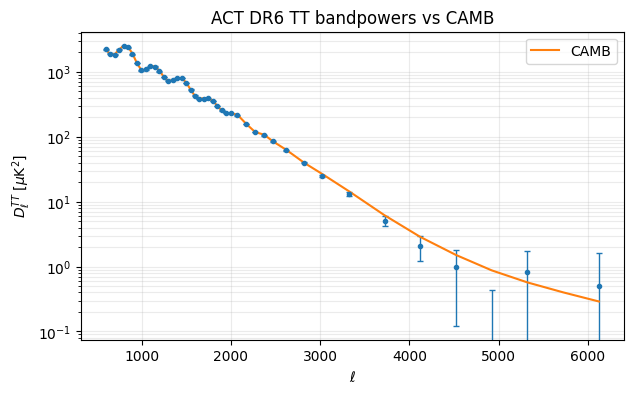

In [1]:
import sacc
import numpy as np

path = "/springbrook/share/physics/phubbr/projects/cmb/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits"
s = sacc.Sacc.load_fits(path)

tt_type = "cl_00"
t1, t2 = ("dr6_cmb_s0", "dr6_cmb_s0")

# Preferred method
ells, Cl = s.get_ell_cl(tt_type, t1, t2)

# Convert to D_ell (NO T0 scaling)
fac = ells*(ells+1)/(2*np.pi)
Dl_obs = fac * Cl

# Covariance block for TT
inds = s.indices(tt_type, (t1, t2))
cov_full = np.asarray(s.covariance.covmat, float)
cov_Cl = cov_full[np.ix_(inds, inds)]
cov_Dl = cov_Cl * fac[:, None] * fac[None, :]



tt_type = "cl_00"
t1, t2 = ("dr6_cmb_s0", "dr6_cmb_s0")

# Get ell + mean bandpowers + covariance block
ells, mu, cov_block = s.get_ell_cl(tt_type, t1, t2, return_cov=True)
Dl_obs = np.array(mu, dtype=float)
cov_Dl = np.array(cov_block, dtype=float)

print("Loaded TT bins:", len(ells))
print("ell range:", ells.min(), ells.max())
print("Dl range:", Dl_obs.min(), Dl_obs.max())
print("cov_Dl shape:", cov_Dl.shape)



import camb
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

ell_act = np.asarray(ells, dtype=float)
Dl_act  = np.asarray(Dl_obs, dtype=float)
sigma = np.sqrt(np.diag(cov_Dl))
# CAMB must reach ACT max ell (~6123)
lmax_act = int(np.ceil(ell_act.max())) + 50

# ---- Fiducial cosmology (Planck-like) ----
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.02237, omch2=0.12, mnu=0.06, omk=0.0, tau=0.054)
pars.InitPower.set_params(As=2.1e-9, ns=0.9649, r=0)
pars.set_for_lmax(lmax_act, lens_potential_accuracy=1)

results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit="muK")

# Use lensed/total TT for high-ell ACT comparisons
Dl_model_full = powers["total"][:lmax_act+1, 0]  # D_ell^{TT} [muK^2]
ell_model = np.arange(Dl_model_full.size)

# Interpolate theory onto ACT bin centers
Dl_model_at_act = interp1d(
    ell_model, Dl_model_full, kind="linear",
    bounds_error=False, fill_value="extrapolate"
)(ell_act)

plt.figure(figsize=(7,4))
plt.errorbar(ells, Dl_obs, yerr=sigma, fmt="o",markersize=3, capsize=2, linewidth=1)
#plt.plot(ells, Dl_obs, "o", markersize=3, label="ACT DR6 TT bandpowers")
plt.plot(ell_act, Dl_model_at_act, "-", linewidth=1.5, label="CAMB")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell^{TT}\;[\mu{\rm K}^2]$")
plt.yscale("log")
#plt.ylim(-20, +20)
plt.grid(True, which="both", alpha=0.25)
plt.title("ACT DR6 TT bandpowers vs CAMB")
plt.legend()
plt.show()

In [2]:
'''# ===========================================================
# Your code + notebook-friendly progress indicators
#   - Per-chain step progress bar (tqdm) with it/s + acceptance so far
#   - Works best with prefer="threads" and small n_chains (e.g. 4–8)
# ===========================================================

import time
t0 = time.perf_counter()


import numpy as np
import camb
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from camb.baseconfig import CAMBParamRangeError
from scipy.interpolate import interp1d
from tqdm.auto import tqdm  # <-- progress bar

# ------------------------------------------------------------
# ACT TT observational data
# ------------------------------------------------------------
ell_act = np.array(ells, dtype=float)
Dl_obs_act = np.array(Dl_obs, dtype=float)
cov_Dl_act = np.array(cov_Dl, dtype=float)

lmax_act = int(np.ceil(ell_act.max())) + 50

# ============================================================
# CAMB model: Dl_TT(theta) for 6 parameters
# ============================================================

THETA_H0_RANGE = (10, 150)

def camb_Dl_TT(thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau, lmax):
    cosmomc_theta = thetaMC_1e4 / 1e4
    As = np.exp(ln1e10As) * 1e-10

    pars = camb.CAMBparams()
    pars.set_cosmology(
        cosmomc_theta=cosmomc_theta,
        ombh2=ombh2,
        omch2=omch2,
        tau=tau,
        theta_H0_range=THETA_H0_RANGE,
    )
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_for_lmax(lmax, lens_potential_accuracy=1)
    pars.WantTensors = False

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit="muK")
    Dl_TT = powers["total"][:lmax+1, 0]  # lensed/total TT
    return Dl_TT

# ============================================================
# Priors + bounds
# ============================================================

BOUNDS = {
    "thetaMC_1e4": (103.0, 105.0),
    "ombh2":       (0.017, 0.027),
    "omch2":       (0.09, 0.15),
    "ns":          (0.9, 1.1),
    "ln1e10As":    (2.6, 3.5),
    "tau":         (0.0, 0.1),
}

names  = ["thetaMC_1e4", "ombh2", "omch2", "ns", "ln1e10As", "tau"]
labels = [r"10^4\,\theta_{\rm MC}", r"\Omega_b h^2", r"\Omega_c h^2",
          r"n_s", r"\ln(10^{10}A_s)", r"\tau"]

def in_bounds(x, lo, hi):
    return (lo <= x) and (x <= hi)

TAU_MU  = 5.66e-2
TAU_SIG = 5.8e-3

def log_prior(p):
    thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau = p
    if not in_bounds(thetaMC_1e4, *BOUNDS["thetaMC_1e4"]): return -np.inf
    if not in_bounds(ombh2,       *BOUNDS["ombh2"]):       return -np.inf
    if not in_bounds(omch2,       *BOUNDS["omch2"]):       return -np.inf
    if not in_bounds(ns,          *BOUNDS["ns"]):          return -np.inf
    if not in_bounds(ln1e10As,    *BOUNDS["ln1e10As"]):    return -np.inf
    if not in_bounds(tau,         *BOUNDS["tau"]):         return -np.inf

    # Gaussian prior on tau
    logp_tau = -0.5 * ((tau - TAU_MU) / TAU_SIG) ** 2 - np.log(TAU_SIG * np.sqrt(2*np.pi))
    return logp_tau

# ============================================================
# Likelihood + target
# ============================================================

def log_likelihood(p):
    thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau = p
    try:
        Dl_model_full = camb_Dl_TT(thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau, lmax=lmax_act)
    except CAMBParamRangeError:
        return -np.inf
    except Exception:
        return -np.inf

    ell_model = np.arange(Dl_model_full.size)
    Dl_model_at_act = interp1d(
        ell_model, Dl_model_full, kind="linear",
        bounds_error=False, fill_value="extrapolate"
    )(ell_act)

    resid = Dl_obs_act - Dl_model_at_act
    try:
        x = np.linalg.solve(cov_Dl_act, resid)
    except np.linalg.LinAlgError:
        return -np.inf

    return -0.5 * float(resid @ x)

def log_target(p):
    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(p)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# ============================================================
# Reflective boundaries
# ============================================================

def reflect_1d(x, lo, hi):
    width = hi - lo
    y = (x - lo) % (2.0 * width)
    return lo + y if y <= width else hi - (y - width)

def reflect_params(p):
    p = list(p)
    for i, key in enumerate(names):
        lo, hi = BOUNDS[key]
        p[i] = reflect_1d(p[i], lo, hi)
    return np.array(p, dtype=float)

# ============================================================
# One MH step
# ============================================================

def mh_step(p_cur, logp_cur, step_scales, rng):
    prop = p_cur + rng.normal(0.0, step_scales, size=len(p_cur))
    prop = reflect_params(prop)
    logp_prop = log_target(prop)
    if np.log(rng.random()) < (logp_prop - logp_cur):
        return prop, logp_prop, True
    return p_cur, logp_cur, False

# ===========================================================
# Starting point + jitter
# ============================================================

p_fid = np.array([104.170, 2.239e-2, 12.00e-2, 0.9729, 3.064, 0.0544], dtype=float)
jitter = np.array([6.7e-5 * 1e4, 2.1e-3, 2.6e-2, 0.061, 0.24, 0.0073], dtype=float)

def find_valid_start(rng, max_tries=200):
    for _ in range(max_tries):
        p0 = p_fid + rng.normal(0.0, jitter, size=6)
        p0 = reflect_params(p0)
        logp0 = log_target(p0)
        if np.isfinite(logp0):
            return p0, logp0
    for _ in range(max_tries):
        p0 = np.array([rng.uniform(*BOUNDS[k]) for k in names], dtype=float)
        p0 = reflect_params(p0)
        logp0 = log_target(p0)
        if np.isfinite(logp0):
            return p0, logp0
    raise RuntimeError("Could not find a valid start; widen THETA_H0_RANGE or tighten priors.")

# ============================================================
# One chain with tqdm progress (shows step rate + acceptance)
# ============================================================

def run_chain_progress(num_steps, step_scales, seed=0, position=0, update_every=25):
    rng = np.random.default_rng(seed)
    p, logp = find_valid_start(rng)

    chain = np.empty((num_steps, 6), dtype=float)
    accepted = 0

    bar = tqdm(total=num_steps, position=position, leave=False,
               desc=f"chain {seed}", mininterval=0.5)

    tstart = time.perf_counter()
    for t in range(num_steps):
        p, logp, acc = mh_step(p, logp, step_scales, rng)
        chain[t] = p
        accepted += int(acc)

        if (t + 1) % update_every == 0 or (t + 1) == num_steps:
            dt = time.perf_counter() - tstart
            rate = (t + 1) / max(dt, 1e-9)
            bar.set_postfix(acc=f"{accepted/(t+1):.3f}", it_s=f"{rate:.1f}")
            bar.update(update_every if (t + 1) % update_every == 0 else (num_steps - bar.n))

    bar.close()
    return chain, accepted / num_steps

# ============================================================
# Multiple chains (NOTE: use threads for clean tqdm in notebooks)
# ============================================================

#step_scales = np.array([1.0e-5 * 1e4, 6.5e-5, 0.0011, 0.0033, 0.0036, 0.0073], dtype=float)
step_scales = np.array([1.0e-5 * 1e4, 6.5e-5, 0.0011, 0.0033, 0.0036, 0.0073], dtype=float)


n_chains  = 1          # keep small in notebooks for readable bars (try 4 or 8)
num_steps = 75840
base_seed = 0

results = Parallel(n_jobs=n_chains, prefer="threads")(
    delayed(run_chain_progress)(num_steps=num_steps, step_scales=step_scales,
                                seed=base_seed + i, position=i)
    for i in range(n_chains)
)

chains = np.array([r[0] for r in results])   # (n_chains, num_steps, 6)
acc_rates = np.array([r[1] for r in results])

print("Acceptance rates:", acc_rates)
print("Mean acceptance:", float(acc_rates.mean()))
print("chains shape:", chains.shape)



burn = 22#752  #30%
samples = chains[:, burn:, :].reshape(-1, 6)

def qsummary(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return q50, (q50 - q16), (q84 - q50)

for i, nm in enumerate(names):
    m, lo, hi = qsummary(samples[:, i])
    print(f"{nm:10s} = {m:.6g}  -{lo:.3g}  +{hi:.3g}")

from getdist import plots, MCSamples
gdsamples = MCSamples(samples=samples, names=names, labels=labels)
g = plots.get_subplot_plotter(width_inch=10)
g.settings.num_plot_contours = 2
g.triangle_plot(gdsamples, filled=True)
plt.show()



t1 = time.perf_counter()
print(f"Elapsed: {t1 - t0:.3f} seconds")

SyntaxError: incomplete input (3306246430.py, line 1)

In [4]:
''''# ===========================================================
# 6-parameter LambdaCDM MH inference using ACT DR6 binned TT data
# + CHECKPOINT / RESUME: saves each chain to disk and resumes later
#
#   p = [thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau]
# Likelihood: Gaussian with ACT TT covariance, model interpolated onto ACT ell bins
# ===========================================================

import os
import time
import numpy as np
import camb
from joblib import Parallel, delayed
from camb.baseconfig import CAMBParamRangeError
from scipy.interpolate import interp1d

# -----------------------------
# REQUIRED: ACT data already in memory as
#   ells   (ACT bin centers, shape ~45)
#   Dl_obs (ACT TT bandpowers, shape ~45)
#   cov_Dl (ACT TT covariance, shape ~45x45)
# -----------------------------
ell_act = np.array(ells, dtype=float)
Dl_obs_act = np.array(Dl_obs, dtype=float)
cov_Dl_act = np.array(cov_Dl, dtype=float)

# CAMB must cover ACT ell range
lmax_act = int(np.ceil(ell_act.max())) + 50

# -----------------------------
# Checkpointing setup
# -----------------------------
CHECKPOINT_DIR = "mh_checkpoints_act"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def checkpoint_path(seed: int) -> str:
    return os.path.join(CHECKPOINT_DIR, f"chain_seed{seed}.npz")

def save_checkpoint(path, chain, t_done, p, logp, accepted, rng_state, num_steps, step_scales):
    np.savez(
        path,
        chain=chain,
        t_done=np.array(t_done, dtype=int),
        p=p,
        logp=np.array(logp, dtype=float),
        accepted=np.array(accepted, dtype=int),
        rng_state=np.array(rng_state, dtype=object),
        num_steps=np.array(num_steps, dtype=int),
        step_scales=np.array(step_scales, dtype=float),
    )

def load_checkpoint(path):
    d = np.load(path, allow_pickle=True)
    chain = d["chain"]
    t_done = int(d["t_done"])
    p = d["p"]
    logp = float(d["logp"])
    accepted = int(d["accepted"])
    rng_state = d["rng_state"].item()
    num_steps = int(d["num_steps"])
    step_scales = d["step_scales"]
    return chain, t_done, p, logp, accepted, rng_state, num_steps, step_scales

def print_checkpoint_status(n_chains, base_seed=0):
    print("Checkpoint status:")
    for i in range(n_chains):
        seed = base_seed + i
        path = checkpoint_path(seed)
        if os.path.exists(path):
            d = np.load(path, allow_pickle=True)
            t_done = int(d["t_done"])
            num_steps = int(d["num_steps"])
            print(f"  seed {seed}: {t_done}/{num_steps} steps done")
        else:
            print(f"  seed {seed}: no checkpoint")

# ============================================================
# CAMB model: Dl_TT(theta) for 6 parameters
# ============================================================

THETA_H0_RANGE = (10, 150)

def camb_Dl_TT(thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau, lmax):
    cosmomc_theta = thetaMC_1e4 / 1e4
    As = np.exp(ln1e10As) * 1e-10  # ln(1e10 As) -> As

    pars = camb.CAMBparams()
    pars.set_cosmology(
        cosmomc_theta=cosmomc_theta,
        ombh2=ombh2,
        omch2=omch2,
        tau=tau,
        theta_H0_range=THETA_H0_RANGE,
    )
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_for_lmax(lmax, lens_potential_accuracy=1)
    pars.WantTensors = False

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit="muK")

    # High-ell ACT comparisons typically use lensed/total TT:
    Dl_TT = powers["total"][:lmax+1, 0]  # D_ell (muK^2)
    return Dl_TT

# ============================================================
# Priors (hard bounds + Gaussian prior on tau)
# ============================================================

BOUNDS = {
    "thetaMC_1e4": (103.0, 105.0),
    "ombh2":       (0.017, 0.027),
    "omch2":       (0.09, 0.15),
    "ns":          (0.9, 1.1),
    "ln1e10As":    (2.6, 3.5),
    "tau":         (0.0, 0.1),
}

names = ["thetaMC_1e4", "ombh2", "omch2", "ns", "ln1e10As", "tau"]

def in_bounds(x, lo, hi):
    return (lo <= x) and (x <= hi)

TAU_MU  = 5.66e-2
TAU_SIG = 5.8e-3

def log_prior(p):
    thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau = p
    if not in_bounds(thetaMC_1e4, *BOUNDS["thetaMC_1e4"]): return -np.inf
    if not in_bounds(ombh2,       *BOUNDS["ombh2"]):       return -np.inf
    if not in_bounds(omch2,       *BOUNDS["omch2"]):       return -np.inf
    if not in_bounds(ns,          *BOUNDS["ns"]):          return -np.inf
    if not in_bounds(ln1e10As,    *BOUNDS["ln1e10As"]):    return -np.inf
    if not in_bounds(tau,         *BOUNDS["tau"]):         return -np.inf

    # Gaussian prior on tau
    logp_tau = -0.5 * ((tau - TAU_MU) / TAU_SIG) ** 2 - np.log(TAU_SIG * np.sqrt(2*np.pi))
    return logp_tau

# ============================================================
# Likelihood + target posterior
# ============================================================

def log_likelihood(p):
    thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau = p
    try:
        Dl_model_full = camb_Dl_TT(thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau, lmax=lmax_act)
    except CAMBParamRangeError:
        return -np.inf
    except Exception:
        return -np.inf

    ell_model = np.arange(Dl_model_full.size)
    Dl_model_at_act = interp1d(
        ell_model, Dl_model_full,
        kind="linear", bounds_error=False, fill_value="extrapolate"
    )(ell_act)

    resid = Dl_obs_act - Dl_model_at_act

    try:
        x = np.linalg.solve(cov_Dl_act, resid)
    except np.linalg.LinAlgError:
        return -np.inf

    return -0.5 * float(resid @ x)

def log_target(p):
    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(p)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# ============================================================
# Reflective boundaries (bounce)
# ============================================================

def reflect_1d(x, lo, hi):
    width = hi - lo
    y = (x - lo) % (2.0 * width)
    return lo + y if y <= width else hi - (y - width)

def reflect_params(p):
    p = list(p)
    for i, key in enumerate(names):
        lo, hi = BOUNDS[key]
        p[i] = reflect_1d(p[i], lo, hi)
    return np.array(p, dtype=float)

# ============================================================
# MH step
# ============================================================

def mh_step(p_cur, logp_cur, step_scales, rng):
    prop = p_cur + rng.normal(0.0, step_scales, size=len(p_cur))
    prop = reflect_params(prop)
    logp_prop = log_target(prop)
    if np.log(rng.random()) < (logp_prop - logp_cur):
        return prop, logp_prop, True
    return p_cur, logp_cur, False

# ============================================================
# Initialization
# ============================================================

p_fid = np.array([104.170, 2.239e-2, 12.00e-2, 0.9729, 3.064, 0.0544], dtype=float)
jitter = np.array([6.7e-5 * 1e4, 2.1e-3, 2.6e-2, 0.061, 0.24, 0.0073], dtype=float)

def find_valid_start(rng, max_tries=300):
    for _ in range(max_tries):
        p0 = p_fid + rng.normal(0.0, jitter, size=6)
        p0 = reflect_params(p0)
        logp0 = log_target(p0)
        if np.isfinite(logp0):
            return p0, logp0
    for _ in range(max_tries):
        p0 = np.array([rng.uniform(*BOUNDS[k]) for k in names], dtype=float)
        p0 = reflect_params(p0)
        logp0 = log_target(p0)
        if np.isfinite(logp0):
            return p0, logp0
    raise RuntimeError("Could not find a valid start; adjust THETA_H0_RANGE/priors.")

# ============================================================
# One chain WITH resume/checkpoint
# ============================================================

def run_chain_resume(num_steps, step_scales, seed=0, save_every=500):
    path = checkpoint_path(seed)

    if os.path.exists(path):
        chain, t_done, p, logp, accepted, rng_state, num_steps_ckpt, _ = load_checkpoint(path)
        if num_steps_ckpt != num_steps:
            raise RuntimeError(f"[seed {seed}] num_steps mismatch: ckpt={num_steps_ckpt} vs current={num_steps}")

        rng = np.random.default_rng(seed)
        rng.bit_generator.state = rng_state
        print(f"[seed {seed}] Resuming from step {t_done}/{num_steps}", flush=True)

    else:
        rng = np.random.default_rng(seed)
        p, logp = find_valid_start(rng)
        chain = np.empty((num_steps, 6), dtype=float)
        t_done = 0
        accepted = 0
        save_checkpoint(path, chain, t_done, p, logp, accepted, rng.bit_generator.state, num_steps, step_scales)
        print(f"[seed {seed}] Starting new chain; checkpoint saved at 0/{num_steps}", flush=True)

    # Main loop
    for t in range(t_done, num_steps):
        p, logp, acc = mh_step(p, logp, step_scales, rng)
        chain[t] = p
        accepted += int(acc)

        if ((t + 1) % save_every == 0) or (t + 1 == num_steps):
            save_checkpoint(path, chain, t + 1, p, logp, accepted, rng.bit_generator.state, num_steps, step_scales)
            print(f"[seed {seed}] saved {t+1}/{num_steps} | acc={accepted/(t+1):.3f}", flush=True)

    return chain, accepted / num_steps

# ============================================================
# Run multiple chains (parallel)
# ============================================================

# Proposal step sizes (edit as needed)
step_scales = np.array([1.0e-5 * 1e4, 6.5e-5, 0.0011, 0.0033, 0.0036, 0.0073], dtype=float)

n_chains  = 1
num_steps = 75840
base_seed = 0
save_every = 2370

print_checkpoint_status(n_chains, base_seed)

t_start = time.perf_counter()
results = Parallel(n_jobs=n_chains, prefer="processes")(
    delayed(run_chain_resume)(num_steps=num_steps, step_scales=step_scales,
                              seed=base_seed + i, save_every=save_every)
    for i in range(n_chains)
)
t_end = time.perf_counter()

chains = np.array([r[0] for r in results])   # (n_chains, num_steps, 6)
acc_rates = np.array([r[1] for r in results])

print("Acceptance rates:", acc_rates)
print("Mean acceptance:", float(acc_rates.mean()))
print("chains shape:", chains.shape)
print(f"Wall time: {t_end - t_start:.1f} s")
print(f"Total elapsed since start: {time.perf_counter() - t0:.1f} s")





# Save trace plots + 1D hists + triangle plot + summary text into a single PDF.
# Assumes you already ran the checkpointed sampler and have:
#   chains   shape (n_chains, num_steps, 6)
#   acc_rates
#   names, labels
# Optionally: set burn and thin.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "my_results_plots.pdf"
burn = 0 # 22752    #30%    
thin = 1        # change to e.g. 5 if you want thinning for smoother plots

# Flatten samples after burn/thin
samples = chains[:, burn::thin, :].reshape(-1, chains.shape[2])

def qsummary(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return q50, (q50 - q16), (q84 - q50)

def add_text_page(pdf, title, lines):
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    fig.text(0.07, 0.95, title, fontsize=14, weight="bold", va="top")
    y = 0.92
    for line in lines:
        fig.text(0.07, y, line, fontsize=10, family="monospace", va="top")
        y -= 0.024
        if y < 0.05:
            pdf.savefig(fig)
            plt.close(fig)
            fig = plt.figure(figsize=(8.27, 11.69))
            y = 0.95
    pdf.savefig(fig)
    plt.close(fig)

with PdfPages(pdf_path) as pdf:

    # ---- Summary text page ----
    lines = []
    lines.append(f"Chains: {chains.shape[0]} | Steps per chain: {chains.shape[1]} | Params: {chains.shape[2]}")
    lines.append(f"Burn-in: {burn} | Thin: {thin}")
    lines.append("")
    lines.append(f"Acceptance rate mean: {float(np.mean(acc_rates)):.4f}")
    lines.append(f"Acceptance rate min/max: {float(np.min(acc_rates)):.4f} / {float(np.max(acc_rates)):.4f}")
    lines.append("")
    lines.append("Posterior summaries (median ± 68% CI):")
    lines.append("")
    for i, nm in enumerate(names):
        m, lo, hi = qsummary(samples[:, i])
        lines.append(f"{nm:12s} = {m:.8g}  -{lo:.3g}  +{hi:.3g}")
    add_text_page(pdf, "ACT DR6 MH Run Summary", lines)

    # ---- Acceptance histogram ----
    fig = plt.figure(figsize=(8,4))
    plt.hist(acc_rates, bins=20)
    plt.xlabel("Acceptance rate per chain")
    plt.ylabel("Count")
    plt.title("Acceptance-rate distribution")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ---- Trace plots (stacked; one page) ----
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 12), sharex=True)
    for j, (nm, lab) in enumerate(zip(names, labels)):
        ax = axes[j]
        for k in range(chains.shape[0]):
            ax.plot(chains[k, :, j], alpha=0.4, linewidth=0.6)
        ax.set_ylabel(lab.replace("$", ""))  # safe for matplotlib
        ax.set_title(nm, loc="left", fontsize=10)
        ax.axvline(burn, linestyle="--", linewidth=1)
    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ---- Trace plots after burn only (stacked; one page) ----
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 12), sharex=True)
    post = chains[:, burn:, :]
    for j, (nm, lab) in enumerate(zip(names, labels)):
        ax = axes[j]
        for k in range(post.shape[0]):
            ax.plot(post[k, :, j], alpha=0.4, linewidth=0.6)
        ax.set_ylabel(lab.replace("$", ""))
        ax.set_title(f"{nm} (post-burn)", loc="left", fontsize=10)
    axes[-1].set_xlabel("Step (post-burn)")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ---- 1D marginals (histograms) ----
    fig, axes = plt.subplots(3, 2, figsize=(10, 10))
    axes = axes.ravel()
    for i, (nm, lab) in enumerate(zip(names, labels)):
        ax = axes[i]
        ax.hist(samples[:, i], bins=60, alpha=0.85)
        ax.set_title(nm)
        ax.set_xlabel(lab.replace("$", ""))
        ax.set_ylabel("Count")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # ---- Triangle plot using GetDist ----
    try:
        from getdist import plots, MCSamples

        gd_labels = [lab.replace("$", "") for lab in labels]  # remove $ for GetDist
        gds = MCSamples(samples=samples, names=names, labels=gd_labels)

        g = plots.get_subplot_plotter(width_inch=10)
        g.settings.num_plot_contours = 2
        g.triangle_plot(gds, filled=True)
        pdf.savefig(g.fig)
        plt.close(g.fig)

    except Exception as e:
        add_text_page(pdf, "GetDist Triangle Plot Error", [str(e)])

print(f"Saved PDF: {pdf_path}")

SyntaxError: incomplete input (1229546051.py, line 1)

In [2]:
# ===========================================================
# 6-parameter LambdaCDM MH inference using ACT DR6 binned TT data
# + CHECKPOINT / RESUME: saves each chain to disk and resumes later
#
#   p = [thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau]
# Likelihood: Gaussian with ACT TT covariance, model interpolated onto ACT ell bins
# ===========================================================

import os
import time
import numpy as np
import camb
from joblib import Parallel, delayed
from camb.baseconfig import CAMBParamRangeError
from scipy.interpolate import interp1d

t0 = time.perf_counter()

# -----------------------------
# REQUIRED: ACT data already in memory as
#   ells   (ACT bin centers, shape ~45)
#   Dl_obs (ACT TT bandpowers, shape ~45)
#   cov_Dl (ACT TT covariance, shape ~45x45)
# -----------------------------
ell_act = np.array(ells, dtype=float)
Dl_obs_act = np.array(Dl_obs, dtype=float)
cov_Dl_act = np.array(cov_Dl, dtype=float)

# CAMB must cover ACT ell range
lmax_act = int(np.ceil(ell_act.max())) + 200

# -----------------------------
# Checkpointing setup
# -----------------------------
CHECKPOINT_DIR = "ACTlike_MH_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def checkpoint_path(seed: int) -> str:
    return os.path.join(CHECKPOINT_DIR, f"chain_seed{seed}.npz")

def save_checkpoint(path, chain, t_done, p, logp, accepted, rng_state, num_steps, step_scales):
    np.savez(
        path,
        chain=chain,
        t_done=np.array(t_done, dtype=int),
        p=p,
        logp=np.array(logp, dtype=float),
        accepted=np.array(accepted, dtype=int),
        rng_state=np.array(rng_state, dtype=object),
        num_steps=np.array(num_steps, dtype=int),
        step_scales=np.array(step_scales, dtype=float),
    )

def load_checkpoint(path):
    d = np.load(path, allow_pickle=True)
    chain = d["chain"]
    t_done = int(d["t_done"])
    p = d["p"]
    logp = float(d["logp"])
    accepted = int(d["accepted"])
    rng_state = d["rng_state"].item()
    num_steps = int(d["num_steps"])
    step_scales = d["step_scales"]
    return chain, t_done, p, logp, accepted, rng_state, num_steps, step_scales

def print_checkpoint_status(n_chains, base_seed=0):
    print("Checkpoint status:")
    for i in range(n_chains):
        seed = base_seed + i
        path = checkpoint_path(seed)
        if os.path.exists(path):
            d = np.load(path, allow_pickle=True)
            t_done = int(d["t_done"])
            num_steps = int(d["num_steps"])
            print(f"  seed {seed}: {t_done}/{num_steps} steps done")
        else:
            print(f"  seed {seed}: no checkpoint")

# ============================================================
# CAMB model: Dl_TT(theta) for 6 parameters
# ============================================================

THETA_H0_RANGE = (10, 150)

def camb_Dl_TT(thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau, lmax):
    cosmomc_theta = thetaMC_1e4 / 1e4
    As = np.exp(ln1e10As) * 1e-10  # ln(1e10 As) -> As

    pars = camb.CAMBparams()
    pars.set_cosmology(
        cosmomc_theta=cosmomc_theta,
        ombh2=ombh2,
        omch2=omch2,
        tau=tau,
        theta_H0_range=THETA_H0_RANGE,
    )
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_for_lmax(lmax, lens_potential_accuracy=1)
    pars.WantTensors = False

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit="muK")

    # High-ell ACT comparisons typically use lensed/total TT:
    Dl_TT = powers["total"][:lmax+1, 0]  # D_ell (muK^2)
    return Dl_TT

# ============================================================
# Priors ( bounds + Gaussian prior)
# ============================================================

BOUNDS = {
    "thetaMC_1e4": (103.0, 105.0),
    "ombh2":       (0.017, 0.027),
    "omch2":       (0.09, 0.15),
    "ns":          (0.9, 1.1),
    "ln1e10As":    (2.6, 3.5),
    "tau":         (0.0, 0.1),
}

names = ["thetaMC_1e4", "ombh2", "omch2", "ns", "ln1e10As", "tau"]

def in_bounds(x, lo, hi):
    return (lo <= x) and (x <= hi)
# ---- Gaussian prior means/sigmas (use your YAML values) ----
# NOTE: your parameter is thetaMC_1e4 = 1e4 * cosmomc_theta
THETA_MU  = 104.170                 # from 104.170e-4 * 1e4
THETA_SIG = 6.7e-5 * 1e4            # from 6.7e-5 * 1e4 = 0.67

OMBH2_MU  = 2.239e-2
OMBH2_SIG = 2.1e-3 
#OMBH2_SIG = 2.1e-4 

OMCH2_MU  = 12.00e-2
OMCH2_SIG = 2.6e-2
#OMCH2_SIG = 2.6e-3 

NS_MU     = 0.9729
NS_SIG    = 0.061

LOGA_MU   = 3.064                   # ln(1e10 As) == logA
LOGA_SIG  = 0.24

TAU_MU    = 0.0544
TAU_SIG   = 0.0073

LOGSQRT2PI = 0.5*np.log(2*np.pi)

#TAU_MU  = 5.66e-2
#TAU_SIG = 5.8e-3

def log_norm(x, mu, sig):
    z = (x - mu) / sig
    return -0.5*z*z - np.log(sig) - LOGSQRT2PI

def log_prior(p):
    thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau = p

    # Hard bounds (same as you already do)
    if not in_bounds(thetaMC_1e4, *BOUNDS["thetaMC_1e4"]): return -np.inf
    if not in_bounds(ombh2,       *BOUNDS["ombh2"]):       return -np.inf
    if not in_bounds(omch2,       *BOUNDS["omch2"]):       return -np.inf
    if not in_bounds(ns,          *BOUNDS["ns"]):          return -np.inf
    if not in_bounds(ln1e10As,    *BOUNDS["ln1e10As"]):    return -np.inf
    if not in_bounds(tau,         *BOUNDS["tau"]):         return -np.inf

    # Sum of Gaussian log-priors
    lp = 0.0
    lp += log_norm(thetaMC_1e4, THETA_MU, THETA_SIG)
    lp += log_norm(ombh2,       OMBH2_MU, OMBH2_SIG)
    lp += log_norm(omch2,       OMCH2_MU, OMCH2_SIG)
    lp += log_norm(ns,          NS_MU,    NS_SIG)
    lp += log_norm(ln1e10As,    LOGA_MU,  LOGA_SIG)
    lp += log_norm(tau,         TAU_MU,   TAU_SIG)

    return lp

# ============================================================
# Likelihood + target posterior
# ============================================================

def log_likelihood(p):
    thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau = p
    try:
        Dl_model_full = camb_Dl_TT(thetaMC_1e4, ombh2, omch2, ns, ln1e10As, tau, lmax=lmax_act)
    except CAMBParamRangeError:
        return -np.inf
    except Exception:
        return -np.inf

    ell_model = np.arange(Dl_model_full.size)
    Dl_model_at_act = interp1d(
        ell_model, Dl_model_full,
        kind="linear", bounds_error=False, fill_value="extrapolate"
    )(ell_act)

    resid = Dl_obs_act - Dl_model_at_act

    try:
        x = np.linalg.solve(cov_Dl_act, resid)
    except np.linalg.LinAlgError:
        return -np.inf

    return -0.5 * float(resid @ x)

def log_target(p):
    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(p)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# ============================================================
# Reflective boundaries (bounce)
# ============================================================

def reflect_1d(x, lo, hi):
    width = hi - lo
    y = (x - lo) % (2.0 * width)
    return lo + y if y <= width else hi - (y - width)

def reflect_params(p):
    p = list(p)
    for i, key in enumerate(names):
        lo, hi = BOUNDS[key]
        p[i] = reflect_1d(p[i], lo, hi)
    return np.array(p, dtype=float)

# ============================================================
# MH step
# ============================================================

def mh_step(p_cur, logp_cur, step_scales, rng):
    prop = p_cur + rng.normal(0.0, step_scales, size=len(p_cur))
    prop = reflect_params(prop)
    logp_prop = log_target(prop)
    if np.log(rng.random()) < (logp_prop - logp_cur):
        return prop, logp_prop, True
    return p_cur, logp_cur, False

# ============================================================
# Initialization
# ============================================================

p_fid = np.array([104.170, 2.239e-2, 12.00e-2, 0.9729, 3.064, 0.0544], dtype=float)
jitter = np.array([6.7e-5 * 1e4, 2.1e-3, 2.6e-2, 0.061, 0.24, 0.0073], dtype=float)

def find_valid_start(rng, max_tries=300):
    for _ in range(max_tries):
        p0 = p_fid + rng.normal(0.0, jitter, size=6)
        p0 = reflect_params(p0)
        logp0 = log_target(p0)
        if np.isfinite(logp0):
            return p0, logp0
    for _ in range(max_tries):
        p0 = np.array([rng.uniform(*BOUNDS[k]) for k in names], dtype=float)
        p0 = reflect_params(p0)
        logp0 = log_target(p0)
        if np.isfinite(logp0):
            return p0, logp0
    raise RuntimeError("Could not find a valid start; adjust THETA_H0_RANGE/priors.")

# ============================================================
# One chain WITH resume/checkpoint
# ============================================================

def run_chain_resume(num_steps, step_scales, seed=0, save_every=500):
    t_chain_start = time.perf_counter()
    path = checkpoint_path(seed)

    if os.path.exists(path):
        chain, t_done, p, logp, accepted, rng_state, num_steps_ckpt, _ = load_checkpoint(path)
        if num_steps_ckpt != num_steps:
            raise RuntimeError(f"[seed {seed}] num_steps mismatch: ckpt={num_steps_ckpt} vs current={num_steps}")

        rng = np.random.default_rng(seed)
        rng.bit_generator.state = rng_state
        print(f"[seed {seed}] Resuming from step {t_done}/{num_steps}", flush=True)

    else:
        rng = np.random.default_rng(seed)
        p, logp = find_valid_start(rng)
        chain = np.empty((num_steps, 6), dtype=float)
        t_done = 0
        accepted = 0
        save_checkpoint(path, chain, t_done, p, logp, accepted, rng.bit_generator.state, num_steps, step_scales)
        print(f"[seed {seed}] Starting new chain; checkpoint saved at 0/{num_steps}", flush=True)

    for t in range(t_done, num_steps):
        p, logp, acc = mh_step(p, logp, step_scales, rng)
        chain[t] = p
        accepted += int(acc)

        if ((t + 1) % save_every == 0) or (t + 1 == num_steps):
            save_checkpoint(path, chain, t + 1, p, logp, accepted, rng.bit_generator.state, num_steps, step_scales)

            elapsed = time.perf_counter() - t_chain_start
            rate = (t + 1) / max(elapsed, 1e-9)
            
            remaining = num_steps - (t + 1)
            eta_sec = remaining / max(rate, 1e-9)
            print(
            f"[seed {seed}] saved {t+1}/{num_steps} | acc={accepted/(t+1):.3f} | {rate:.2f} steps/s | elapsed={elapsed/60:.1f} min | ETA={eta_sec/60:.1f} min",
            flush=True
            )
    
    t_chain_end = time.perf_counter()    
    runtime_sec = t_chain_end - t_chain_start
    return chain, accepted / num_steps, runtime_sec

# ============================================================
# Run multiple chains (parallel)
# ============================================================

# Proposal step sizes (edit as needed)
step_scales = np.array([1.0e-5 * 1e4, 6.5e-5, 0.0011, 0.0033, 0.0036, 0.0073], dtype=float)
#step_scales = np.array([0.5e-5 * 1e4, 3.5e-5, 0.0005, 0.0015, 0.0015, 0.0033], dtype=float)


n_chains  = 1
num_steps = 75840
base_seed = 0
save_every = num_steps//20 

print_checkpoint_status(n_chains, base_seed)

t_start = time.perf_counter()
results = Parallel(n_jobs=n_chains, prefer="processes")(
    delayed(run_chain_resume)(num_steps=num_steps, step_scales=step_scales,
                              seed=base_seed + i, save_every=save_every)
    for i in range(n_chains)
)
t_end = time.perf_counter()

chains = np.array([r[0] for r in results])   # (n_chains, num_steps, 6)
acc_rates = np.array([r[1] for r in results])
runtimes = np.array([r[2] for r in results])

print("Acceptance rates:", acc_rates)
print("Mean acceptance:", float(acc_rates.mean()))
print("chains shape:", chains.shape)
print("Chain runtimes (s):", runtimes)
print("Mean runtime (s):", float(runtimes.mean()))
print("Steps/sec per chain (mean):", float(num_steps / runtimes.mean()))
print(f"Wall time: {t_end - t_start:.1f} s")
print(f"Total elapsed since start: {time.perf_counter() - t0:.1f} s")





import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ---------------------------
# Settings (edit these)
# ---------------------------
CHECKPOINT_DIR = "ACTlike_MH_checkpoints"   # must match your sampler
n_chains = 1                            # set to how many you ran
base_seed = 0
burn = int(num_steps * 0.3)
thin = 1
pdf_path = "My_results_plots_ACTlike.pdf"

names  = ["thetaMC_1e4", "ombh2", "omch2", "ns", "ln1e10As", "tau"]
labels = [r"10^4\,\theta_{\rm MC}", r"\Omega_b h^2", r"\Omega_c h^2",
          r"n_s", r"\ln(10^{10}A_s)", r"\tau"]

def checkpoint_path(seed):
    return os.path.join(CHECKPOINT_DIR, f"chain_seed{seed}.npz")

# ---------------------------
# Load chains from checkpoints
# ---------------------------
chains_list = []
acc_rates = []

for i in range(n_chains):
    seed = base_seed + i
    path = checkpoint_path(seed)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing checkpoint: {path}")

    d = np.load(path, allow_pickle=True)
    chain = d["chain"]                # full allocated array (num_steps, 6)
    t_done = int(d["t_done"])         # how many steps were actually computed
    accepted = int(d["accepted"])

    if t_done == 0:
        raise RuntimeError(f"Chain seed {seed} has t_done=0 (no samples yet).")

    chain = chain[:t_done, :]         # keep only computed part
    chains_list.append(chain)
    acc_rates.append(accepted / t_done)

# Pad to same length for stacking (optional). If all equal, this is fine.
min_len = min(c.shape[0] for c in chains_list)
chains = np.stack([c[:min_len, :] for c in chains_list], axis=0)  # (n_chains, min_len, 6)
acc_rates = np.array(acc_rates)

print("Loaded chains:", chains.shape, "| mean acceptance:", float(acc_rates.mean()))

# ---------------------------
# Prepare samples
# ---------------------------
burn_eff = min(burn, chains.shape[1] - 1)
samples = chains[:, burn_eff::thin, :].reshape(-1, chains.shape[2])

def qsummary(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return q50, (q50 - q16), (q84 - q50)

def add_text_page(pdf, title, lines):
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    fig.text(0.07, 0.95, title, fontsize=14, weight="bold", va="top")
    y = 0.92
    for line in lines:
        fig.text(0.07, y, line, fontsize=10, family="monospace", va="top")
        y -= 0.024
        if y < 0.05:
            pdf.savefig(fig); plt.close(fig)
            fig = plt.figure(figsize=(8.27, 11.69)); y = 0.95
    pdf.savefig(fig); plt.close(fig)

# ---------------------------
# Write PDF
# ---------------------------
with PdfPages(pdf_path) as pdf:

    # Summary page
    lines = [
        f"Checkpoint dir: {CHECKPOINT_DIR}",
        f"Chains loaded: {chains.shape[0]}",
        f"Steps per chain used (min_len): {chains.shape[1]}",
        f"Burn-in used: {burn_eff}",
        f"Thin: {thin}",
        "",
        f"Acceptance mean: {float(acc_rates.mean()):.4f}",
        f"Acceptance min/max: {float(acc_rates.min()):.4f} / {float(acc_rates.max()):.4f}",
        "",
        "Posterior summaries (median ± 68% CI):",
        ""
    ]
    for i, nm in enumerate(names):
        m, lo, hi = qsummary(samples[:, i])
        lines.append(f"{nm:12s} = {m:.8g}  -{lo:.3g}  +{hi:.3g}")
    add_text_page(pdf, "ACT DR6 MH Results Summary", lines)

    # Acceptance histogram
    fig = plt.figure(figsize=(8,4))
    plt.hist(acc_rates, bins=max(5, min(20, len(acc_rates))))
    plt.xlabel("Acceptance rate per chain")
    plt.ylabel("Count")
    plt.title("Acceptance-rate distribution")
    plt.tight_layout()
    pdf.savefig(fig); plt.close(fig)

    # Trace plots (stacked)
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 12), sharex=True)
    for j, (nm, lab) in enumerate(zip(names, labels)):
        ax = axes[j]
        for k in range(chains.shape[0]):
            ax.plot(chains[k, :, j], alpha=0.4, linewidth=0.6)
        ax.axvline(burn_eff, linestyle="--", linewidth=1)
        ax.set_ylabel(lab.replace("$",""))
        ax.set_title(nm, loc="left", fontsize=10)
    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    pdf.savefig(fig); plt.close(fig)

    # 1D marginals
    fig, axes = plt.subplots(3, 2, figsize=(10, 10))
    axes = axes.ravel()
    for i, (nm, lab) in enumerate(zip(names, labels)):
        axes[i].hist(samples[:, i], bins=60, alpha=0.85)
        axes[i].set_title(nm)
        axes[i].set_xlabel(lab.replace("$",""))
        axes[i].set_ylabel("Count")
    plt.tight_layout()
    pdf.savefig(fig); plt.close(fig)

    # Triangle plot (GetDist)
    try:
        from getdist import plots, MCSamples
        gd_labels = [lab.replace("$","") for lab in labels]
        gds = MCSamples(samples=samples, names=names, labels=gd_labels)
        g = plots.get_subplot_plotter(width_inch=10)
        g.settings.num_plot_contours = 2
        g.triangle_plot(gds, filled=True)
        pdf.savefig(g.fig)
        plt.close(g.fig)
    except Exception as e:
        add_text_page(pdf, "GetDist Triangle Plot Error", [str(e)])

print(f"Saved PDF: {pdf_path}")

Checkpoint status:
  seed 0: 75840/75840 steps done
[seed 0] Resuming from step 75840/75840
Acceptance rates: [0.07207278]
Mean acceptance: 0.07207278481012658
chains shape: (1, 75840, 6)
Chain runtimes (s): [0.00371121]
Mean runtime (s): 0.0037112096324563026
Steps/sec per chain (mean): 20435385.631882105
Wall time: 0.0 s
Total elapsed since start: 0.0 s
Loaded chains: (1, 75840, 6) | mean acceptance: 0.07207278481012658
Removed no burn in
Saved PDF: My_results_plots_ACTlike.pdf
